In [85]:
import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
import joblib

In [86]:
df=pd.read_csv(
    "../data/processed/zomato_cleaned.csv"
)

In [87]:
df.head()

,url,address,name,online_order,book_table,rate,votes,location,rest_type,cuisines,approx_costfor_two_people,listed_intype,listed_incity,popularity_score,price_tier,locality_avg_rating,above_locality_avg,rest_type_count,cuisine_count,log_votes
0,https://www.zomato.com/bangalore/jalsa-banasha...,"942, 21st Main Road, 2nd Stage, Banashankari, ...",Jalsa,1,1,4.1,775,Banashankari,Casual Dining,"North Indian, Mughlai, Chinese",800.0,Buffet,Banashankari,3177.5,high,3.647350,1,1,3,6.654153
1,https://www.zomato.com/bangalore/spice-elephan...,"2nd Floor, 80 Feet Road, Near Big Bazaar, 6th ...",Spice Elephant,1,0,4.1,787,Banashankari,Casual Dining,"Chinese, North Indian, Thai",800.0,Buffet,Banashankari,3226.7,high,3.647350,1,1,3,6.669498
2,https://www.zomato.com/SanchurroBangalore?cont...,"1112, Next to KIMS Medical College, 17th Cross...",San Churro Cafe,1,0,3.8,918,Banashankari,"Cafe, Casual Dining","Cafe, Mexican, Italian",800.0,Buffet,Banashankari,3488.4,high,3.647350,1,2,3,6.823286
3,https://www.zomato.com/bangalore/addhuri-udupi...,"1st Floor, Annakuteera, 3rd Stage, Banashankar...",Addhuri Udupi Bhojana,0,0,3.7,88,Banashankari,Quick Bites,"South Indian, North Indian",300.0,Buffet,Banashankari,325.6,low,3.647350,1,1,2,4.488636
4,https://www.zomato.com/bangalore/grand-village...,"10, 3rd Floor, Lakshmi Associates, Gandhi Baza...",Grand Village,0,0,3.8,166,Basavanagudi,Casual Dining,"North Indian, Rajasthani",600.0,Buffet,Banashankari,630.8,medium,3.681463,1,1,2,5.117994


In [88]:
df.shape

(12140, 20)

In [89]:
df.columns

Index(['url', 'address', 'name', 'online_order', 'book_table', 'rate', 'votes',
       'location', 'rest_type', 'cuisines', 'approx_costfor_two_people',
       'listed_intype', 'listed_incity', 'popularity_score', 'price_tier',
       'locality_avg_rating', 'above_locality_avg', 'rest_type_count',
       'cuisine_count', 'log_votes'],
      dtype='str')

In [90]:
df.isnull().sum()

url                          0
address                      0
name                         0
online_order                 0
book_table                   0
rate                         0
votes                        0
location                     0
rest_type                    0
cuisines                     0
approx_costfor_two_people    0
listed_intype                0
listed_incity                0
popularity_score             0
price_tier                   0
locality_avg_rating          0
above_locality_avg           0
rest_type_count              0
cuisine_count                0
log_votes                    0
dtype: int64

In [91]:
df['approx_cost']=df['approx_costfor_two_people']/2
df[['approx_cost',"approx_costfor_two_people"]]

,approx_cost,approx_costfor_two_people
0,400.0,800.0
1,400.0,800.0
2,400.0,800.0
3,150.0,300.0
4,300.0,600.0
...,...,...
12135,200.0,400.0
12136,200.0,400.0
12137,200.0,400.0
12138,200.0,400.0


In [92]:
features=[
    "rate",
    "votes",
    "approx_cost",
    'popularity_score',
    "locality_avg_rating",
    "above_locality_avg",
    "rest_type_count",
    "cuisine_count",
    "log_votes"
]

In [93]:
X=df[features]

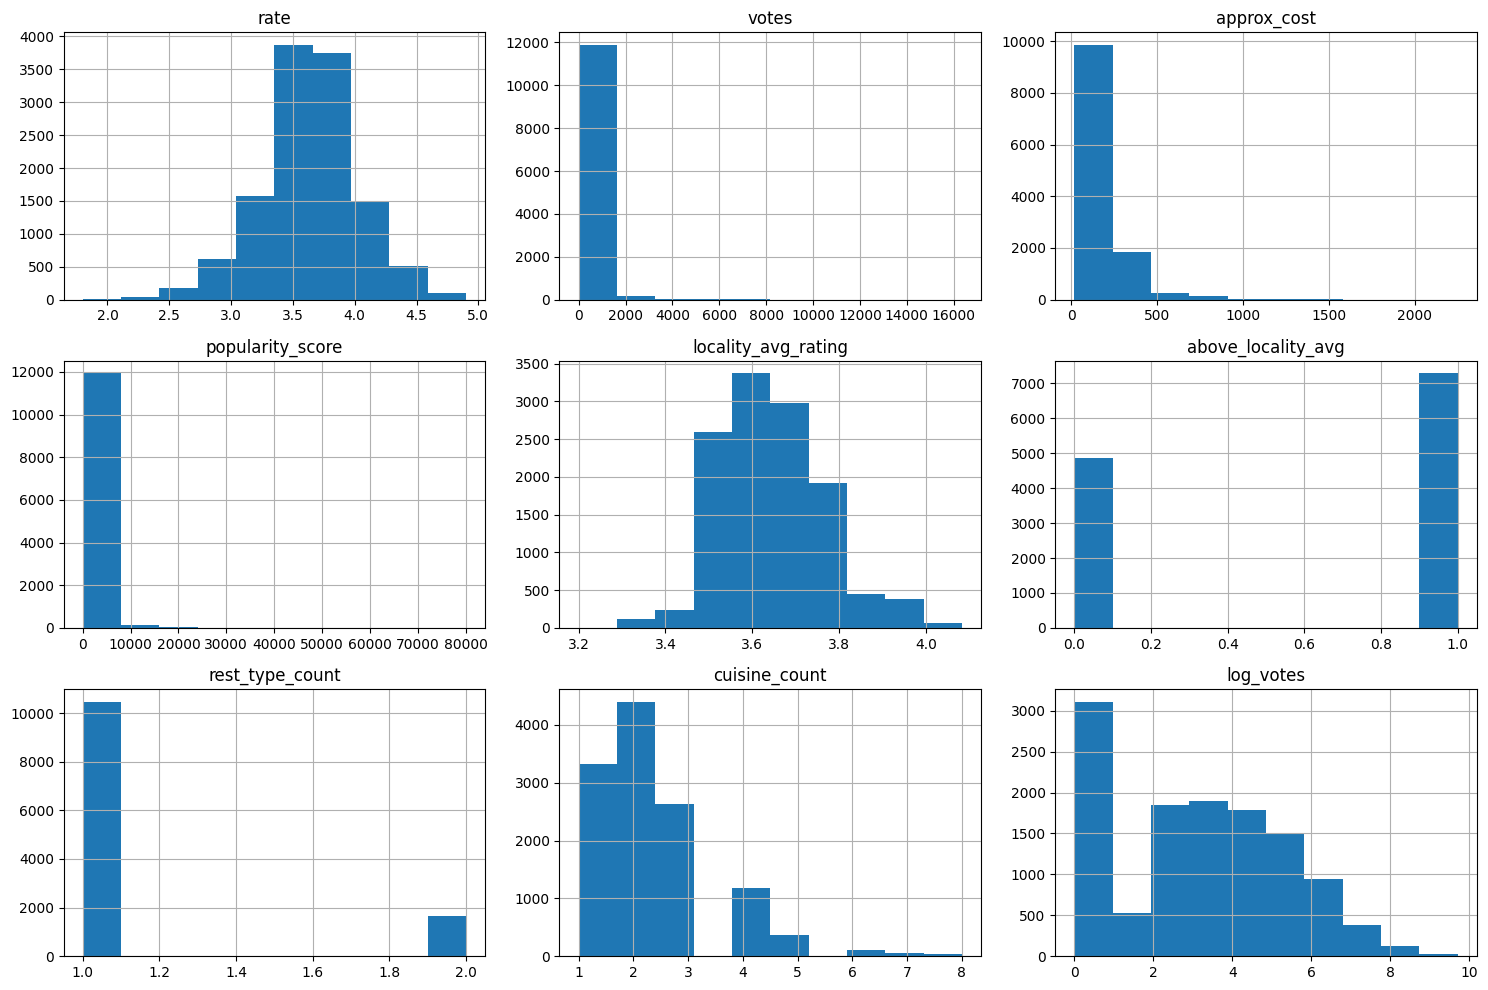

In [94]:
X.hist(
    figsize=(15,10)
)
plt.tight_layout()
plt.show()

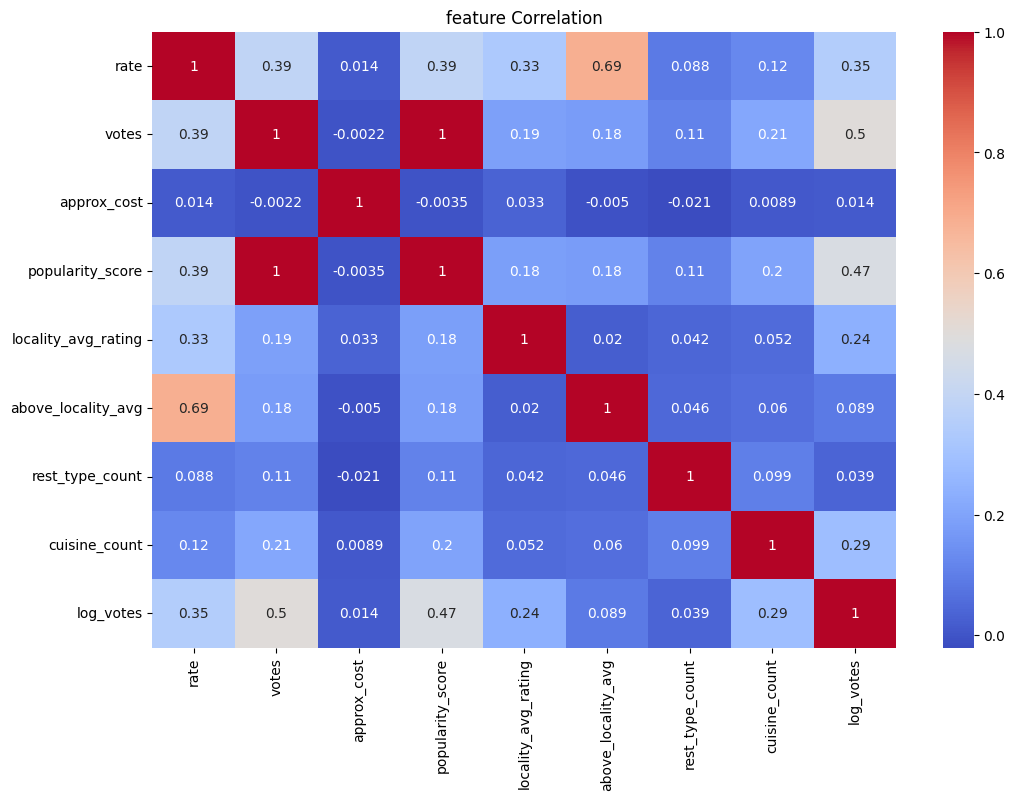

In [95]:
plt.figure(figsize=(12,8))
sns.heatmap(
    X.corr(),
    annot=True,
    cmap="coolwarm"
)
plt.title("feature Correlation")

plt.show()

In [96]:
scaler=StandardScaler()
X_scaled=scaler.fit_transform(X)

In [97]:
wcss=[]

In [98]:
for k in range(2,11):
    kmeans=KMeans(
        n_clusters=k,
    random_state=42,
    n_init=10
    )
    kmeans.fit(X_scaled)
    wcss.append(
        kmeans.inertia_
    )

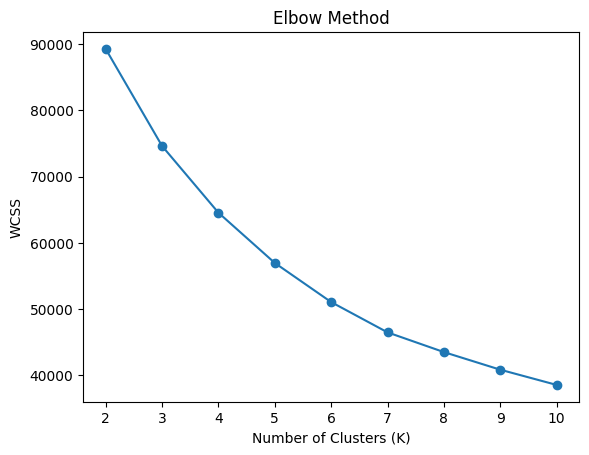

In [99]:
plt.Figure(figsize=(8,5))
plt.plot(
    range(2,11),
    wcss,
    marker="o"
)
plt.xlabel("Number of Clusters (K)")
plt.ylabel("WCSS")
plt.title("Elbow Method")

plt.savefig(
    "../images/elbow_plot.png"
)
plt.show()

In [100]:
silhouette_scores=[]

In [101]:
for k in range(2,11):
    kmeans=KMeans(
        n_clusters=k,
        random_state=42,
        n_init=10
    )
    labels=kmeans.fit_predict(
        X_scaled
    )
    score=silhouette_score(
        X_scaled,
        labels
    )
    silhouette_scores.append(score)

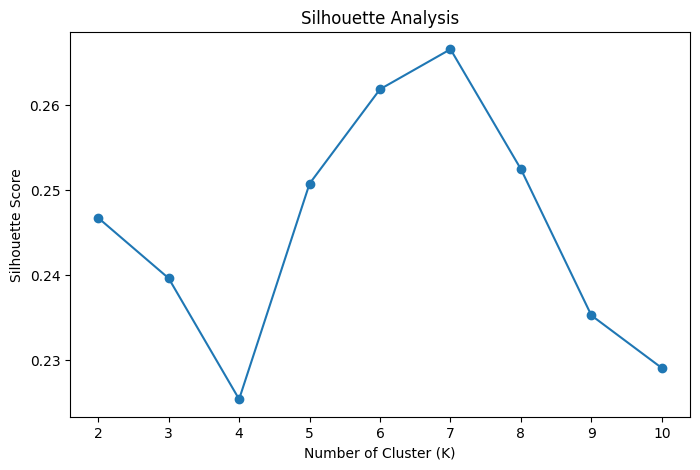

In [106]:
plt.figure(figsize=(8,5))

plt.plot(
    range(2,11),
    silhouette_scores,
    marker="o"
    )
plt.xlabel("Number of Cluster (K)")
plt.ylabel("Silhouette Score")
plt.title("Silhouette Analysis")
plt.savefig(
    "../images/silhouette_scores.png",
    bbox_inches="tight"
)
plt.show()

In [108]:
kmeans=KMeans(
    n_clusters=7,
    random_state=42,
    n_init=10
)

In [109]:
df['cluster']=kmeans.fit_predict(
    X_scaled
)

In [110]:
joblib.dump(
    kmeans,
    "../models/kmeans_model.plk"
)

['../models/kmeans_model.plk']

In [111]:
joblib.dump(
    scaler,
    "../models/scaler.pkl"
)

['../models/scaler.pkl']

In [112]:
df['cluster'].value_counts()

cluster
3    4100
1    3030
6    2748
2    1470
5     442
0     300
4      50
Name: count, dtype: int64

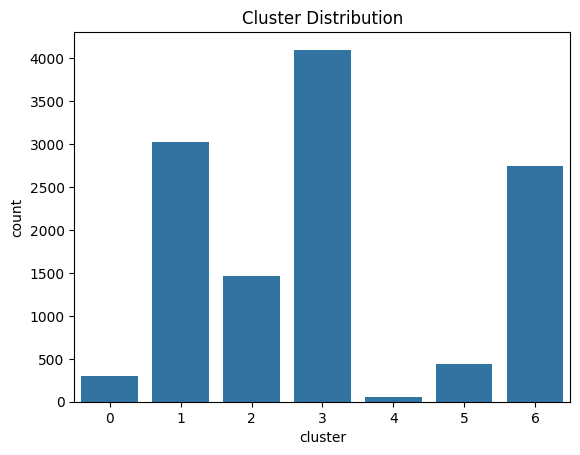

In [113]:
sns.countplot(
    x=df['cluster']
)
plt.title("Cluster Distribution")
plt.show()

In [116]:
cluster_profiles=(df.groupby("cluster")[features].mean()).reset_index()

In [117]:
cluster_profiles

,cluster,rate,votes,approx_cost,popularity_score,locality_avg_rating,above_locality_avg,rest_type_count,cuisine_count,log_votes
0,0,3.659833,144.710000,813.250000,565.250333,3.660915,0.570000,1.060000,2.380000,3.167763
1,1,3.946716,234.459076,204.974587,941.931188,3.655039,0.983828,1.000000,2.585479,5.004213
2,2,3.629082,82.372109,202.860544,323.976395,3.629916,0.609524,2.000000,2.447619,2.746062
3,3,3.302122,48.877073,202.193049,155.130854,3.622149,0.000000,1.000000,2.175366,2.806263
4,4,4.518000,6650.760000,194.500000,30264.474000,3.749806,1.000000,1.500000,3.480000,8.736789
5,5,4.267195,1787.488688,209.128959,7667.146606,3.750321,0.984163,1.368778,3.608597,7.391468
6,6,3.648399,5.876638,199.675400,21.517576,3.589078,1.000000,1.000000,1.901747,0.729343


In [118]:
cluster_profiles.to_csv(
    "../reports/cluster_profiles.csv"
)

In [119]:
cluster_names = {

    0: "Expensive Low-Popularity Restaurants",

    1: "Popular Affordable Restaurants",

    2: "Diversified Mid-Tier Restaurants",

    3: "Low Performing Restaurants",

    4: "Viral Premium Restaurants",

    5: "Highly Popular Premium Restaurants",

    6: "Hidden or New Restaurants"
}

df['cluster_name']=df['cluster'].map(cluster_names)

In [120]:
df.to_csv(
    "../data/processed/zomato_clustered.csv",
    index=False
)

In [121]:
silhouette_df = pd.DataFrame({

    "K": range(2,11),

    "Silhouette_Score": silhouette_scores
})
silhouette_df.to_csv(
    "../reports/silhouette_scores.csv",
    index=False
)

# Hour 1 Conclusions

1. Restaurant segmentation was performed using K-Means clustering.
2. Engineered behavioral features improved cluster quality.
3. Feature scaling was applied because K-Means relies on Euclidean distance.
4. Elbow and silhouette analysis were used to determine optimal cluster count.
5. Four meaningful restaurant segments were identified.
6. Cluster profiling enabled business interpretation of customer segments.